### Testing File

In [1]:
from langchain.tools import tool
from langchain.chat_models import init_chat_model

# Initialize the model, using Haiku for now, but should prob change to sonnet once things are working

model = init_chat_model("claude-haiku-4-5-20251001")

/home/ruben/CLBuilder/agentic_CL_builder/.venv/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (6.0.0.post1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


In [4]:
# Setting up RAG and context stuff

from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma
# from langchain_openai import OpenAIEmbeddings
from langchain_huggingface import HuggingFaceEmbeddings
import os

# 1. Load all PDFs in your personal context folder
context_folder = "./personal_context/"
documents = []
for file in os.listdir(context_folder):
    if file.endswith(".pdf"):
        loader = PyPDFLoader(os.path.join(context_folder, file))
        documents.extend(loader.load())

# 2. Chunk the text so the LLM can find specific experiences
text_splitter = RecursiveCharacterTextSplitter(chunk_size=600, chunk_overlap=100)
chunks = text_splitter.split_documents(documents)

# 3. Initialize BGE-M3
# This will download the model (~2GB) on the first run
model_name = "BAAI/bge-m3"
model_kwargs = {'device': 'cpu'} # Change to 'cuda' if you have a GPU
encode_kwargs = {'normalize_embeddings': True}

bge_embeddings = HuggingFaceEmbeddings(
    model_name=model_name,
    model_kwargs=model_kwargs,
    encode_kwargs=encode_kwargs
)

# 3. Create the Vector Store
vectorstore = Chroma.from_documents(
    documents=chunks, 
    embedding=bge_embeddings,
    persist_directory="./chroma_db"
)
retriever = vectorstore.as_retriever(search_kwargs={"k": 5})

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

In [5]:
# Define tools for the researcher node

from mcp import ClientSession, StdioServerParameters
from mcp.client.stdio import stdio_client
from langchain_core.tools import Tool

from langchain_tavily import TavilySearch
from crawl4ai import AsyncWebCrawler

from langchain_core.tools import tool

tavily_tool = TavilySearch(
    max_results=3,
)


@tool
async def web_crawler_tool(url: str) -> str:
    """
    Crawls a website and returns its clean markdown content. 
    Use this for extracting detailed information from job postings or company pages.
    """
    async with AsyncWebCrawler() as crawler:
        # arun fetches the page and converts it to LLM-ready markdown
        result = await crawler.arun(url=url)
        
        if result.success:
            return result.markdown
        else:
            return f"Failed to crawl {url}: {result.error_message}"




# setup the Context Matcher



# Augment the LLM with tools
tools = [tavily_tool, web_crawler_tool]
tools_by_name = {tool.name: tool for tool in tools}
model_with_tools = model.bind_tools(tools)

In [6]:
from langchain.messages import AnyMessage
from typing_extensions import TypedDict, Annotated
import operator
from typing import List

# Build state that will be used to store everything


class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage],operator.add]
    llm_calls: int
    job_url: str
    job_desc: str
    company_research: str
    resume_context: List[str]
    writing_sample: str
    selected_experiences: List[str]
    draft_letter: str
    critique: str
    final_pdf_path: str
    iteration_count: int

In [7]:
from langchain.messages import SystemMessage, ToolMessage


#main agent

def llm_call(state: dict):
    """LLM decides whether to call a tool or not"""
    return {
        "messages": [
            model_with_tools.invoke(
                [
                    SystemMessage(
                        content="""You are a helpful researcher tasked with using your tools to take in a given request, and 
                        perform the necessary tool calls to fill out the company research and job description fields in the State. 
                        Take the URL that is given to you,and perform a Crawl scrape on it, which gets saved to job_desc. Based on 
                        whatever company that job description is for, then perform a Tavily search to find out general company values,
                        mission statements, and beliefs that characterize the work and style of that company, this will then be saved 
                        into company_research. You do not need to know the specific information extracted from either tool, that is
                        handled and saved to the state by the tool itself. Proceed once both tasks are complete. Do not summarize or
                        discuss what was extracted, simply call the necessary tools, and move on."""
                    )
                ]
                + state["messages"]
            )
        ],
        "llm_calls": state.get('llm_calls', 0) + 1
    }



#tool node with tool calls

async def tool_node(state: AgentState):
    """Unified tool node that extracts and summarizes results directly into the state."""
    last_message = state["messages"][-1]
    tool_messages = []
    
    # Use local variables to build the update dictionary
    updated_company_research = state.get("company_research", "")
    updated_job_desc = state.get("job_desc", "")
    updated_job_url = state.get("job_url", "")

    for tool_call in last_message.tool_calls:
        tool_name = tool_call["name"]
        
        # 1. HANDLE COMPANY RESEARCH (TAVILY)
        if "tavily" in tool_name.lower():
            query = tool_call["args"].get("query", "")
            raw_result = await tavily_tool.ainvoke({"query": query})
            
            summary_prompt = f"Summarize the company values and mission from this research in 3-5 sentences. CONTENT:{raw_result}"
            summary = await model.ainvoke(summary_prompt)
            
            updated_company_research = summary.content
            tool_messages.append(ToolMessage(
                content="Company research summarized and saved.", 
                tool_call_id=tool_call["id"]
            ))

        # 2. HANDLE JOB DESCRIPTION (CRAWL4AI)
        elif tool_name == "web_crawler_tool":

            url = tool_call["args"].get("url", "")
            raw_markdown = await web_crawler_tool.ainvoke({"url": url})
            
            summary_prompt = f"""
                Extract only the job responsibilities, requirements, and benefits from the following markdown.
                Ignore navigation menus, footer links, and application form fields (dropdowns, questions).
                
                CONTENT: {raw_markdown}
                """
            summary = await model.ainvoke(summary_prompt)
            
            updated_job_desc = summary.content
            updated_job_url = url
            tool_messages.append(ToolMessage(
                content="Job description summarized and saved.", 
                tool_call_id=tool_call["id"]
            ))
            
        # 3. SAFETY FALLBACK (Prevents the 400 error)
        else:
            print("\n Entering Else Statement!")
            tool_messages.append(ToolMessage(
                content="Tool executed but result not summarized.", 
                tool_call_id=tool_call["id"]
            ))

    return {
        "company_research": updated_company_research,
        "job_desc": updated_job_desc,
        "job_url": updated_job_url,
        "messages": tool_messages
    }


In [8]:
from langchain_mcp_adapters.client import MultiServerMCPClient
from langchain_core.messages import HumanMessage, AIMessage

async def context_engine_node(state: AgentState):
    """
    Combined node: Retrieves context from RAG & MCP, then selects the best 
    experiences to highlight based on the job description.
    """
    job_requirements = state["job_desc"]
    
    # --- STEP 1: RAG RETRIEVAL ---
    # Find experiences in your resumes that match the job description
    relevant_docs = await retriever.ainvoke(job_requirements)
    resume_text = "\n\n".join([doc.page_content for doc in relevant_docs])

    # --- STEP 2: MCP FILESYSTEM (Writing Style) ---
    # 1. Initialize the client (No longer a context manager)
    client = MultiServerMCPClient({
        "filesystem": {
            "command": "npx",
            "args": ["-y", "@modelcontextprotocol/server-filesystem", "./personal_context/samples"],
            "transport": "stdio"
        }
    })

    # 2. Use the .session() context manager for the 'filesystem' server
    async with client.session("filesystem") as session:
        # 3. Call the tool through the session
        writing_sample_data = await session.call_tool(
            "read_file", 
            {"path": "sample_cover_letter.txt"} # Ensure this path is correct relative to the server root
        )
        
        # Extract content (MCP content is usually a list of TextContent/ImageContent objects)
        if hasattr(writing_sample_data, 'content') and writing_sample_data.content:
            writing_style = writing_sample_data.content[0].text
        else:
            writing_style = str(writing_sample_data)



    # --- STEP 3: EXPERIENCE SELECTION (The Reasoning) ---
    selection_prompt = f"""
    You are an expert Career Strategist. Compare the JOB REQUIREMENTS with the RESUME CONTEXT.
    
    JOB REQUIREMENTS:
    {job_requirements}
    
    RESUME CONTEXT:
    {resume_text}
    
    TASK:
    Identify exactly 2-3 specific experiences or 'wins' from the resume context that are the STRONGEST 
    matches for this role. Be specific and data-driven.
    
    Output only the 3 bullet points. Don't include any explanations or additional content over why those points were chose.
    """
    
    selection_response = await model.ainvoke(selection_prompt)
    selected_points = selection_response.content.split("\n")

    return {
        "resume_context": [resume_text],
        "writing_sample": writing_style,
        "selected_experiences": selected_points,
        "messages": [AIMessage(content=f"Strategist: Selected {len(selected_points)} key experiences.")]
    }

In [9]:
from typing import Literal
from langgraph.graph import StateGraph, START, END

#conditional function to determine which node to go to next

def should_continue(state: AgentState):
    messages = state["messages"]
    last_message = messages[-1]

    if not last_message.tool_calls:
        return END

    destinations = []
    for tool_call in last_message.tool_calls:
        tool_name = tool_call["name"]
        if tool_name == "web_crawler_tool":
            destinations.append("research_job")
        elif tool_name in ["tavily_search_results_json", "tavily_tool"]:
            destinations.append("company_research")
            
    return destinations if destinations else END


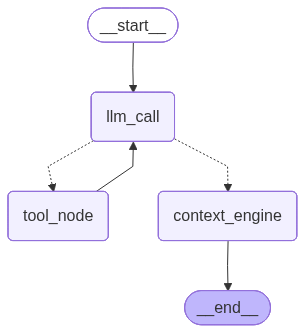

In [10]:
from langgraph.graph import StateGraph, START, END

agent_builder = StateGraph(AgentState)
agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("tool_node", tool_node)  # Single unified node
agent_builder.add_node("context_engine",context_engine_node) # with RAG and FileSystem MCP

def should_continue(state: AgentState):
    last_message = state["messages"][-1]
    if not last_message.tool_calls:
        return "context_engine"
    return "tool_node"

agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges(
    "llm_call",
    should_continue,
    ["tool_node", "context_engine"]
)
agent_builder.add_edge("tool_node", "llm_call")
agent_builder.add_edge("context_engine",END)

agent = agent_builder.compile()

#display graph for debugging purposes/flow

from IPython.display import Image, display
try:
    display(Image(agent.get_graph(xray=True).draw_mermaid_png()))
except:
    pass


In [11]:
# Invoke/Attempt flow


from langchain.messages import HumanMessage

request = [HumanMessage(content="Scrape the listing from this website: https://job-boards.greenhouse.io/figureai/jobs/4609306006. Also extract the company information of that listing")]

# messages = [HumanMessage(content="Search the web for SpaceX culture, and broad company missions statements")]

messages = await agent.ainvoke({"messages": request})
for m in messages["messages"]:
    m.pretty_print()

[INIT].... → Crawl4AI 0.8.0 

[FETCH]... ↓ https://job-boards.greenhouse.io/figureai/jobs/4609306006                                            |
✓ | ⏱: 2.35s 

[SCRAPE].. ◆ https://job-boards.greenhouse.io/figureai/jobs/4609306006                                            |
✓ | ⏱: 0.06s 

[COMPLETE] ● https://job-boards.greenhouse.io/figureai/jobs/4609306006                                            |
✓ | ⏱: 2.44s 

================================ Human Message =================================

Scrape the listing from this website: https://job-boards.greenhouse.io/figureai/jobs/4609306006. Also extract the company information of that listing
================================== Ai Message ==================================

[{'text': "I'll scrape the job listing and extract company information for you.", 'type': 'text'}, {'id': 'toolu_01KHFVXeJLxNtSRsNLaNFXL5', 'caller': {'type': 'direct'}, 'input': {'url': 'https://job-boards.greenhouse.io/figureai/jobs/4609306006'}, 'name': 'web_crawler_tool', 'type': 'tool_use'}, {'id': 'toolu_01E5WiWs4WCGLN8FVkLXn8Jk', 'caller': {'type': 'direct'}, 'input': {'query': 'Figure AI company mission values culture beliefs', 'search_depth': 'advanced'}, 'name': 'tavily_search', 'type': 'tool_use'}]
Tool Calls:
  web_crawler_tool (toolu_01KHFVXeJLxNtSRsNLaNFXL5)
 Call ID: toolu_01KHFVXeJLxNtSRsNLaNFXL5
  Args:
    url: https://job-boards.greenhouse.io/figureai/jobs/46

In [16]:
#evaluate output

import textwrap


print(messages["resume_context"][0])

# selected_exp_lists = messages["selected_experiences"]

# print(textwrap.fill(selected_exp_lists[4], width=40))

# print(textwrap.fill(messages["job_desc"], width=40))

# print(textwrap.fill(messages["job_desc"], width=40))


for a wheeled-quadruped robot, including low-level CAN firmware, dynamically-aware Task-Space Control, dynamics
modeling, and multi-threaded control firmware development in C/C++.
MBOT: SLAM & Exploration | University of Michigan Designed and programmed an advanced feedback and
feedforward low-level wheel speed controller, gyrodometry, and pure pursuit waypoint following in C for a wheeled
robot platform. Developed and validated a SLAM system, A* path planning, and frontier exploration from scratch.

for a wheeled-quadruped robot, including low-level CAN firmware, dynamically-aware Task-Space Control, dynamics
modeling, and multi-threaded control firmware development in C/C++.
MBOT: SLAM & Exploration | University of Michigan Designed and programmed an advanced feedback and
feedforward low-level wheel speed controller, gyrodometry, and pure pursuit waypoint following in C for a wheeled
robot platform. Developed and validated a SLAM system, A* path planning, and frontier exploration fro